<a href="https://colab.research.google.com/github/matveyrei27/aol-scicomp/blob/main/AOLSciCompColab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AOL Scientific Computing
Matvey Reignard Setiawan - 2902671303


In [ ]:
# Import library and data

import numpy as np
import matplotlib.pyplot as plt
import math

y = np.array([
    1863,1614,2570,1685,2101,1811,2457,2171,2134,2502,2358,2399,2048,2523,2086,
    2391,2150,2340,3129,2277,2964,2997,2747,2862,3405,2677,2749,2755,2963,3161,
    3623,2768,3141,3439,3601,3531,3477,3376,4027,3175,3274,3334,3964,3649,3502,
    3688,3657,4422,4197,4441,4736,4521,4485,4644,5036,4876,4789,4544,4975,5211,
    4880,4933,5079,5339,5232,5520,5714,5260,6110,5334,5988,6235,6365,6266,6345,
    6118,6497,6278,6638,6590,6271,7246,6584,6594,7092,7326,7409,7976,7959,8012,
    8195,8008,8313,7791,8368,8933,8756,8613,8705,9098,8769,9544,9050,9186,10012,
    9685,9966,10048,10244,10740,10318,10393,10986,10635,10731,11749,11849,12123,
    12274,11666,11960,12629,12915,13051,13387,13309,13732,13162,13644,13808,14101,
    13992,15191,15018,14917,15046,15556,15893,16388,16782,16716,17033,16896,17689])
x = np.linspace(1, len(y), len(y), dtype=int)

## 1. Mathematical model of bag production

Model: y = 1937.0139 * 1.0155^x


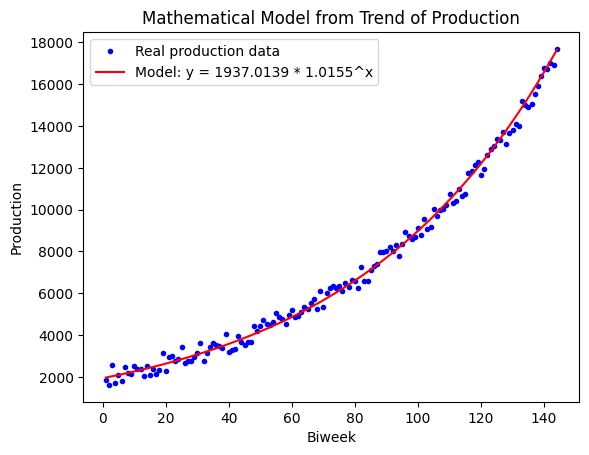

In [ ]:
# 1.
# Formula I'm using: y = a * b ^ x
# ln y=  ln a + x * ln b
# Z = A + x * B
# A = mean(Z) - B * mean(x)
# B = ( n * sum (x * Z) - sum(x) * sum (Z) ) / n * sum(x^2) - (sum(x))^2

n = len(y)
Z = np.log(y)
B = (n * np.sum(x * Z) - np.sum(x) * np.sum(Z)) / (n * np.sum(x**2) - (np.sum(x))**2)
A = np.mean(Z) - B * np.mean(x)

b = (math.e)**B
a = (math.e)**A

print(f"Model: y = {a:.4f} * {b:.4f}^x")

def f(x):
  return a * (b ** x)

y_reg = f(x)

plt.plot(x, y, 'b.', label="Real production data")
plt.plot(x, y_reg, 'r', label=f"Model: y = {a:.4f} * {b:.4f}^x")
plt.legend()
plt.xlabel("Biweek")
plt.ylabel("Production")
plt.title("Mathematical Model from Trend of Production")
plt.show()

## 2. Numerical model of bag production

Langrange error for degree 0: 4278.8744 	 | error / max production = 24.1895%
Langrange error for degree 1: 4726.0286 	 | error / max production = 26.7173%
Langrange error for degree 2: 3479.9410 	 | error / max production = 19.6729%
Langrange error for degree 3: 1921.8022 	 | error / max production = 10.8644%
Langrange error for degree 4: 849.0543 	 | error / max production = 4.7999%
Langrange error for degree 5: 312.5943 	 | error / max production = 1.7672%
Langrange error for degree 6: 98.6461 	 | error / max production = 0.5577%
Langrange error for degree 7: 27.2387 	 | error / max production = 0.1540%
Langrange error for degree 8: 2.0533 	 | error / max production = 0.0116%


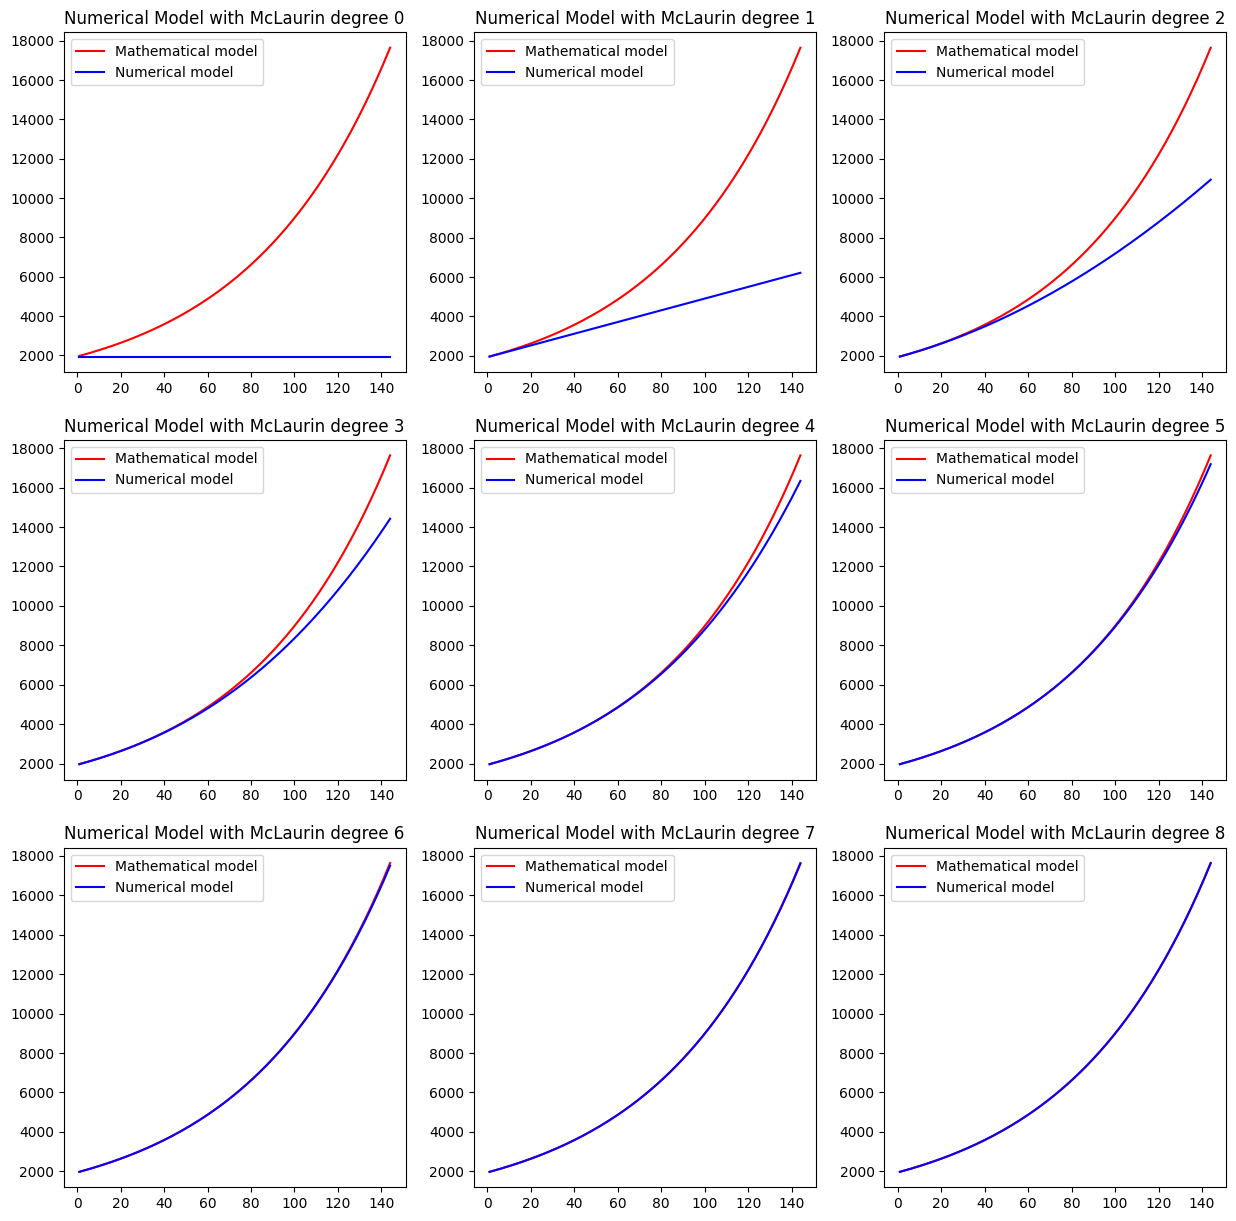

In [278]:
# 2
# y = 1937.014 * 1.015^x                      y(0) = 1937.014
# y' = 1937.014 * ln(1.015) * 1.015^x        y'(0) = 1937.014 * ln(1.015)
# y'' = 1937.014 * ln(1.015)^2 * 1.015^x    y''(0) = 1937.014 * ln(1.015)^2
# y''' = 1937.014 * ln(1.015)^3 * 1.015^x
# using mclaurin:
# y = y(0) * x^0 / 0! + y'(0) * x^1 / 1! + y''(0) + x^2 / 2! ...
# y = sigma(y^i (0) * x^i / i!)
#   = sigma(1937.014 * ln(1.015)^i * x^i / i!)

# langrange_error = mc_laurin with (degree + 1)

def mc_laurin(x, i):
  return a * math.log(b)**i * x**i / math.factorial(i)

# degree of 8 has langrange error of 6.68, and error/max production of 0.03% (below 0.1%), therefore i default value is 8
def num_model(x, i=8):
  if (isinstance(x, (int, np.float64, float))):
    result = 0
  else:
    result = np.zeros(len(x));

  for k in range(i+1): # i+1 so it still runs when starting from 0
    result = result + mc_laurin(x, k)

  return result

def langrange_error(x, i):
  return mc_laurin(np.max(x), i + 1)

plt.figure(figsize=(15,15))

for i in range(0, 9):
  y_appr = num_model(x, i)
  print(f"Langrange error for degree {i}: {langrange_error(x, i):.4f} \t | error / max production = {langrange_error(x, i) / np.max(y)*100:.4f}%")
  plt.subplot(3, 3, i + 1)
  plt.plot(x, y_reg, 'r', label="Mathematical model")
  plt.plot(x, y_appr, 'b', label="Numerical model")
  plt.legend()
  plt.title(f"Numerical Model with McLaurin degree {i}")

plt.show()

##3. Suitable time for warehouse construction

Suitable time (biweek) to build new warehouse: 95 (exact: 95.55694580078125)
Production 26 biweeks after time: 12499.9804
Therefore warehouse is built just on time.


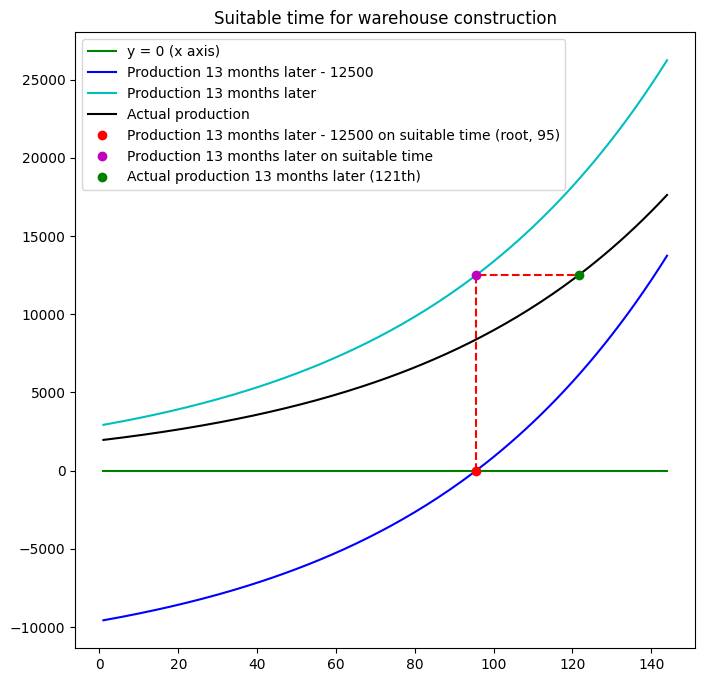

In [273]:
# 3.

def f_new(x):
  # x+26 because construction needs to be 13 months (26 biweeks) early
  # since the data is biweekly, the warehouse storage is divided in half (25000/month = 12500/biweek)
  return num_model(x+26) - 12500

def g_new(x):
  return math.log(b) * num_model(x+26)

# since the production data are in the thousands, tolerance=0.1 can be considered accurate.
def bisection(a, b, tolerance=0.1):
  if (np.sign(f_new(a)) == np.sign(f_new(b))):
    print("Invalid coordinate")
    return None

  c = (a + b) / 2

  # print(f"c = {c:.4f}") # uncomment this to see result every iteration
  if (np.abs(f_new(c)) < tolerance):
    # print(f"Root found at {c:.4f}")
    return c
  elif (np.sign(f_new(c)) == np.sign(f_new(a))):
    return bisection(c, b, tolerance)
  else:
    return bisection(a, c, tolerance)

plt.figure(figsize=(8, 8))
root = bisection(70, 120)
print(f"Suitable time (biweek) to build new warehouse: {math.floor(root)} (exact: {root})")
print(f"Production 26 biweeks after time: {num_model(root+26):.4f}")
print("Therefore warehouse is built just on time.")
# lines
plt.plot(x, np.zeros(len(x)), 'g', label="y = 0 (x axis)")
plt.plot(x, f_new(x), 'b', label="Production 13 months later - 12500")
plt.plot(x, num_model(x+26), 'c', label="Production 13 months later")
plt.plot([root, root, root+26], [0, 12500, 12500], "--r")
plt.plot(x, num_model(x), 'k', label='Actual production')
# dots
plt.plot(root, 0, "ro", label="Production 13 months later - 12500 on suitable time (root, 95)")
plt.plot(root, num_model(root+26), "mo", label="Production 13 months later on suitable time")
plt.plot(root+26, num_model(root+26), 'go', label="Actual production 13 months later (121st)")
plt.legend()
plt.title("Suitable time for warehouse construction")
plt.show()


## 4a. Rate of change from 2020 - 2021

In [ ]:
# 4a.
# (ini kalo array, kurangin 1)
# 2018 -> 1 - 24
# 2019 -> 25 - 48
# 2020 -> 49 - 72
# 2021 -> 73 - 96
# 2020 - 2021 -> 49 - 96
def central(a, y, h=1):
  return (- y[a - h] + y[a + h]) / (2 * h)

def forward(a, y, h=1):
  return (-3 * y[a] + 4 * y[a + h] - y[a + 2 * h]) / (2 * h)

def backward(a, y, h=1):
  return (3 * y[a] - 4 * y[a - h] + y[a - 2 * h]) / (2 * h)

def derive(x, y, start, end):
  y_der = np.zeros(len(x))

  for a in x:
    a = int(a) - 1
    if a == start:
      y_der[a - start] = forward(a, y)
    elif a == end:
      y_der[a - start] = backward(a, y)
    else:
      y_der[a - start] = central(a, y)

  return y_der

y_der = derive(x[48:96], y, 48, 96)
y_der_enum = enumerate(y_der)

print("=== Biweekly ===")
print(f"Steepest increase: {np.max(y_der)} on biweek {np.argmax(y_der) + 1}")
print(f"Steepest decrease: {np.min(y_der)} on biweek {np.argmin(y_der) + 1}")

y_der = y_der[::2] + y_der[1::2] # change into monthly
print("=== Monthly ===")
print(f"Steepest increase: {np.max(y_der)} on month {np.argmax(y_der) + 1}")
print(f"Steepest decrease: {np.min(y_der)} on month {np.argmin(y_der) + 1}")

=== Biweekly ===
Steepest increase: 571.0 on biweek 47
Steepest decrease: -326.0 on biweek 35
=== Monthly ===
Steepest increase: 765.0 on month 24
Steepest decrease: -85.5 on month 2


## 4b. Culmulative bag production

In [ ]:
# 4b.

first = 1
last = 144
n = 144
width = (last - first) / (n - 1)

real_sum = np.sum(y)
trapezoidal = width * (y[0] + 2 * np.sum(y[1:-1]) + y[-1]) / 2
simpson = width * (3 / 8 * (y[0] + 3 * np.sum(y[1:-3:3]) + 3 * np.sum(y[2:-3:3]) + 2 * np.sum(y[3:-3:3]) + y[-3]) + 1 / 3 * (y[-3] + 4 * y[-2] + y[-1]))

print(f"Trapezoidal: {trapezoidal}")
print(f"Simpson: {simpson}")
print(f"Real sum: {real_sum}")

print(f"Trapezoidal error: {np.abs((real_sum - trapezoidal) / real_sum) * 100:.4f}%")
print(f"Simpson error: {np.abs((real_sum - simpson) / real_sum) * 100:.4f}%")

Trapezoidal: 1020969.0
Simpson: 1020243.625
Real sum: 1030745
Trapezoidal error: 0.9484%
Simpson error: 1.0188%
